In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Audio, display
from pynwb import NWBHDF5IO

import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, IntSlider, FloatSlider, Dropdown, Checkbox

from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz

In [2]:
# Define paths
path_bids = './SingleWordProductionDutch-iBIDS'
path_output = './features'
path_results = './results'

# Create directories if they don't exist
os.makedirs(path_output, exist_ok=True)
os.makedirs(path_results, exist_ok=True)

In [3]:
# Initialize decoder
decoder = CustomBrainAudioDecoder(
    path_bids=path_bids,
    path_output=path_output,
    path_results=path_results,
    win_length=0.05,
    frameshift=0.01,
    model_order=4,
    step_size=5,
    n_components=50
)

CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False


In [4]:
visualizer = BrainAudioDecoderViz(decoder)

BrainAudioDecoderViz: Initialized with DEBUG_MODE=False
BrainAudioDecoderViz: Initializing visualization with debug_mode=False


In [5]:
participants = decoder.load_participants()
print(f"Found {len(participants)} participants")

# Alternative: Explicitly define all participants
all_participants = [f'sub-{i:02d}' for i in range(1, 11)]
print(f"All participants: {all_participants}")

Found 10 participants:
  1. sub-01
  2. sub-02
  3. sub-03
  4. sub-04
  5. sub-05
  6. sub-06
  7. sub-07
  8. sub-08
  9. sub-09
  10. sub-10
Found 10 participants
All participants: ['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05', 'sub-06', 'sub-07', 'sub-08', 'sub-09', 'sub-10']


In [6]:
# Choose a participant to analyze
participant_id = 'sub-01'

# Check if features are already extracted
if not os.path.exists(os.path.join(path_output, f'{participant_id}_feat.npy')):
    print(f"Extracting features for {participant_id}...")
    decoder.extract_features_for_participant(participant_id)
else:
    print(f"Features already extracted for {participant_id}")

Features already extracted for sub-01


In [7]:
# Load participants
participants = decoder.load_participants()
print(f"Found {len(participants)} participants")
participants.head()

Found 10 participants:
  1. sub-01
  2. sub-02
  3. sub-03
  4. sub-04
  5. sub-05
  6. sub-06
  7. sub-07
  8. sub-08
  9. sub-09
  10. sub-10
Found 10 participants


,participant_id,age,sex,hand
0,sub-01,20,F,NaN
1,sub-02,43,M,NaN
2,sub-03,24,M,NaN
3,sub-04,46,F,NaN
4,sub-05,50,F,NaN


In [8]:
participant_id = 'sub-02'

# Check if features already exist
if not os.path.exists(os.path.join(path_output, f'{participant_id}_feat.npy')):
    print(f"Extracting features for {participant_id}...")
    features, spectrogram, words, feature_names = decoder.extract_features_for_participant(participant_id)
else:
    print(f"Loading existing features for {participant_id}...")
    features, spectrogram, words, feature_names = decoder.load_features(participant_id)

print(f"Feature shape: {features.shape}")
print(f"Spectrogram shape: {spectrogram.shape}")
print(f"Words shape: {words.shape}")
print(f"Number of unique words: {len(np.unique(words))}")

Loading existing features for sub-02...
Feature shape: (29985, 1143)
Spectrogram shape: (29985, 23)
Words shape: (29985,)
Number of unique words: 101


In [9]:
@interact(
    participant_id=Dropdown(
        options=[f'sub-{i:02d}' for i in range(1, 11)],
        value='sub-01',
        description='Participant:'
    ),
    duration=FloatSlider(min=1, max=10, step=0.5, value=3, description='Duration (s):'),
    start_time=FloatSlider(min=0, max=20, step=0.5, value=0, description='Start time (s):'),
    channels=IntSlider(min=1, max=20, step=1, value=8, description='Channels:')
)
def interactive_eeg(participant_id, duration, start_time, channels):
    visualizer.plot_raw_eeg(
        participant_id=participant_id,
        duration=duration,
        start_time=start_time,
        channels_to_plot=channels
    )

interactive(children=(Dropdown(description='Participant:', options=('sub-01', 'sub-02', 'sub-03', 'sub-04', 's…

In [10]:
@interact(
    participant_id=Dropdown(
        options=[f'sub-{i:02d}' for i in range(1, 11)],
        value='sub-01',
        description='Participant:'
    ),
    original=Checkbox(value=True, description='Original'),
    predicted=Checkbox(value=True, description='Predicted'),
    side_by_side=Checkbox(value=True, description='Side by side'),
    log_scale=Checkbox(value=True, description='Log scale')
)
def interactive_spectrogram(participant_id, original, predicted, side_by_side, log_scale):
    # Check if prediction exists
    if predicted and not os.path.exists(os.path.join(path_results, f'{participant_id}_predicted_spec.npy')):
        print(f"Warning: Predicted spectrogram not found for {participant_id}")
        print("Training model first...")
        decoder.train_test_model(participant_id, save_audio=False)
    
    visualizer.plot_spectrogram(
        participant_id=participant_id,
        original=original,
        predicted=predicted,
        side_by_side=side_by_side,
        log_scale=log_scale
    )

interactive(children=(Dropdown(description='Participant:', options=('sub-01', 'sub-02', 'sub-03', 'sub-04', 's…

In [11]:
# @interact(
#     participant_id=Dropdown(
#         options=[f'sub-{i:02d}' for i in range(1, 11)],
#         value='sub-01',
#         description='Participant:'
#     ),
#     original=Checkbox(value=True, description='Original'),
#     predicted=Checkbox(value=True, description='Predicted'),
#     reconstructed=Checkbox(value=True, description='Reconstructed')
# )
# def interactive_audio(participant_id, original, predicted, reconstructed):
#     # Check if audio files exist
#     if predicted and not os.path.exists(os.path.join(path_results, f'{participant_id}_predicted.wav')):
#         print(f"Warning: Predicted audio not found for {participant_id}")
#         print("Training model first...")
#         decoder.train_test_model(participant_id, save_audio=True)
    
#     visualizer.play_audio(
#         participant_id=participant_id,
#         original=original,
#         predicted=predicted,
#         reconstructed=reconstructed
#     )

In [12]:
@interact(
    participant_id=Dropdown(
        options=[f'sub-{i:02d}' for i in range(1, 11)],
        value='sub-01',
        description='Participant:'
    ),
    original=Checkbox(value=True, description='Original'),
    predicted=Checkbox(value=True, description='Predicted'),
    reconstructed=Checkbox(value=True, description='Reconstructed'),
    side_by_side=Checkbox(value=True, description='Side by side')
)
def interactive_waveform(participant_id, original, predicted, reconstructed, side_by_side):
    # Check if audio files exist
    if predicted and not os.path.exists(os.path.join(path_results, f'{participant_id}_predicted.wav')):
        print(f"Warning: Predicted audio not found for {participant_id}")
        print("Training model first...")
        decoder.train_test_model(participant_id, save_audio=True)
    
    visualizer.plot_waveform(
        participant_id=participant_id,
        original=original,
        predicted=predicted,
        reconstructed=reconstructed,
        side_by_side=side_by_side
    )

interactive(children=(Dropdown(description='Participant:', options=('sub-01', 'sub-02', 'sub-03', 'sub-04', 's…

In [13]:
@interact(
    participant_id=Dropdown(
        options=[f'sub-{i:02d}' for i in range(1, 11)],
        value='sub-01',
        description='Participant:'
    )
)
def plot_participant_channels(participant_id):
    visualizer.plot_channels_comparison(participant_id, duration_seconds=3)

interactive(children=(Dropdown(description='Participant:', options=('sub-01', 'sub-02', 'sub-03', 'sub-04', 's…

In [14]:
@interact(
    participant_id=Dropdown(
        options=[f'sub-{i:02d}' for i in range(1, 11)],
        value='sub-01',
        description='Participant:'
    )
)
def analyze_participant_channels(participant_id):
    decoder.analyze_channels(participant_id)

interactive(children=(Dropdown(description='Participant:', options=('sub-01', 'sub-02', 'sub-03', 'sub-04', 's…

In [15]:
# channel_results = decoder.analyze_individual_channels('sub-01')

# # 3. Analyze channels across all participants (this may take a while)
# all_results = decoder.analyze_channels_across_participants()

In [16]:
# 5. Interactive visualization (in Jupyter notebook)
interactive_widget = visualizer.interactive_channel_analysis()
display(interactive_widget)

interactive(children=(Dropdown(description='Channel:', options=('All Channels', 'LA1', 'LA10', 'LA11', 'LA12',…

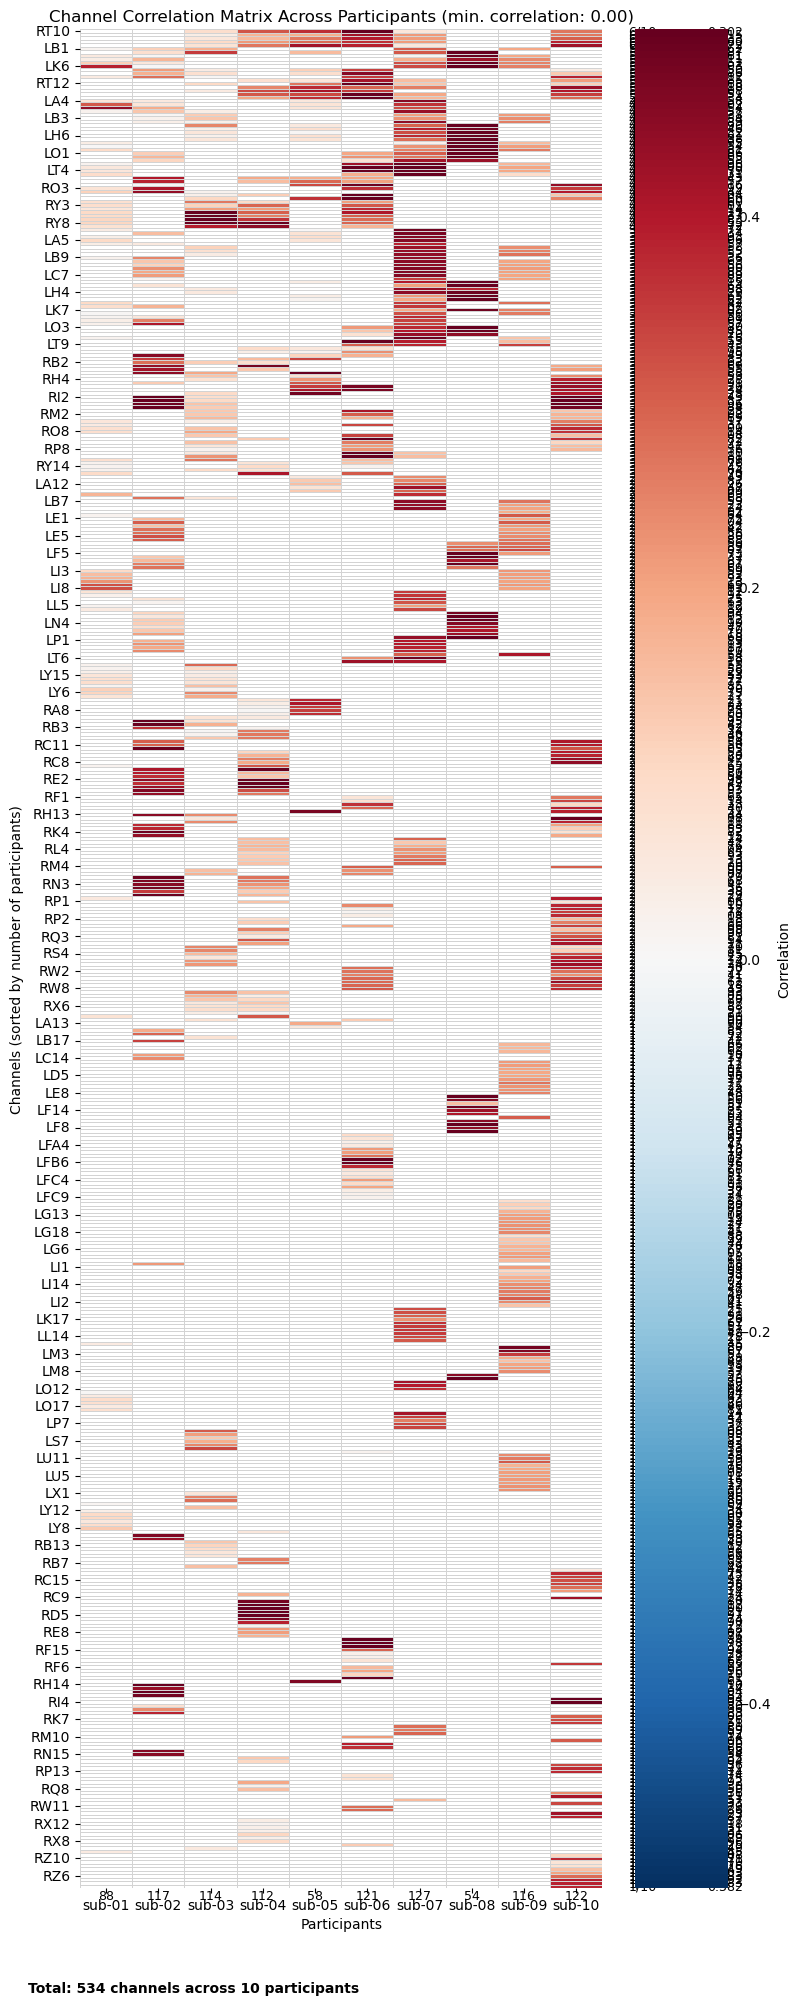

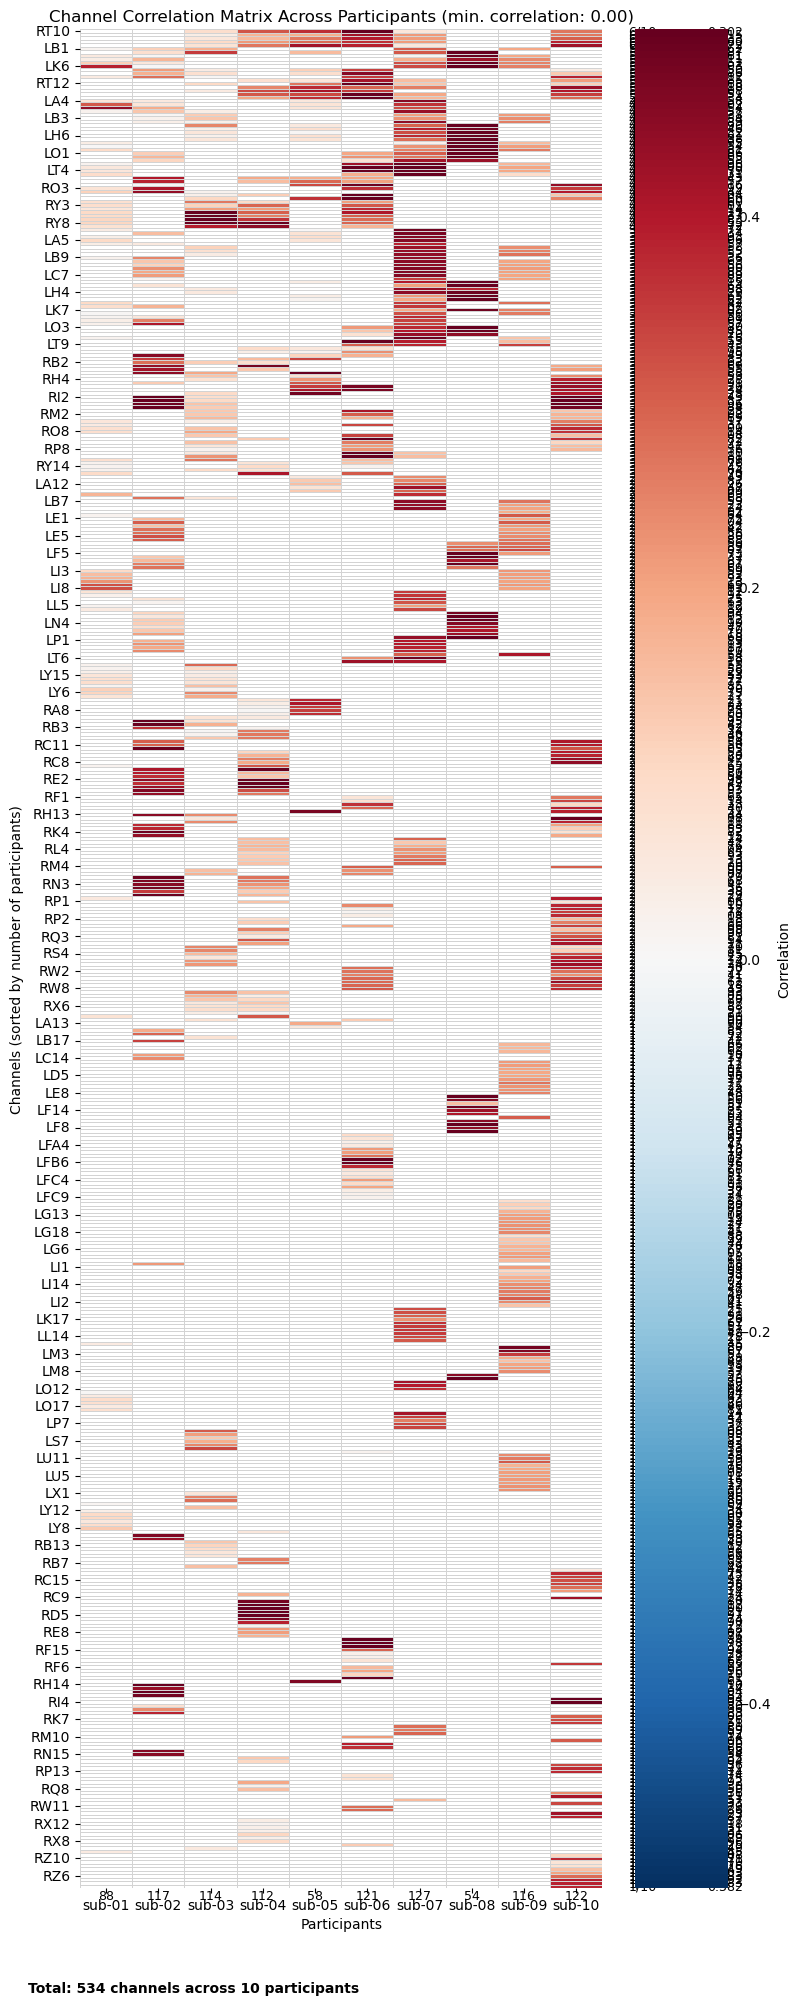

In [17]:
# Interactive exploration (in Jupyter notebook)
interactive_widget = visualizer.plot_channel_matrix()
display(interactive_widget)

In [18]:
# 2. To display the interactive participant selector widget:
from IPython.display import display
selector_widget = visualizer.simple_participant_selector()
display(selector_widget)

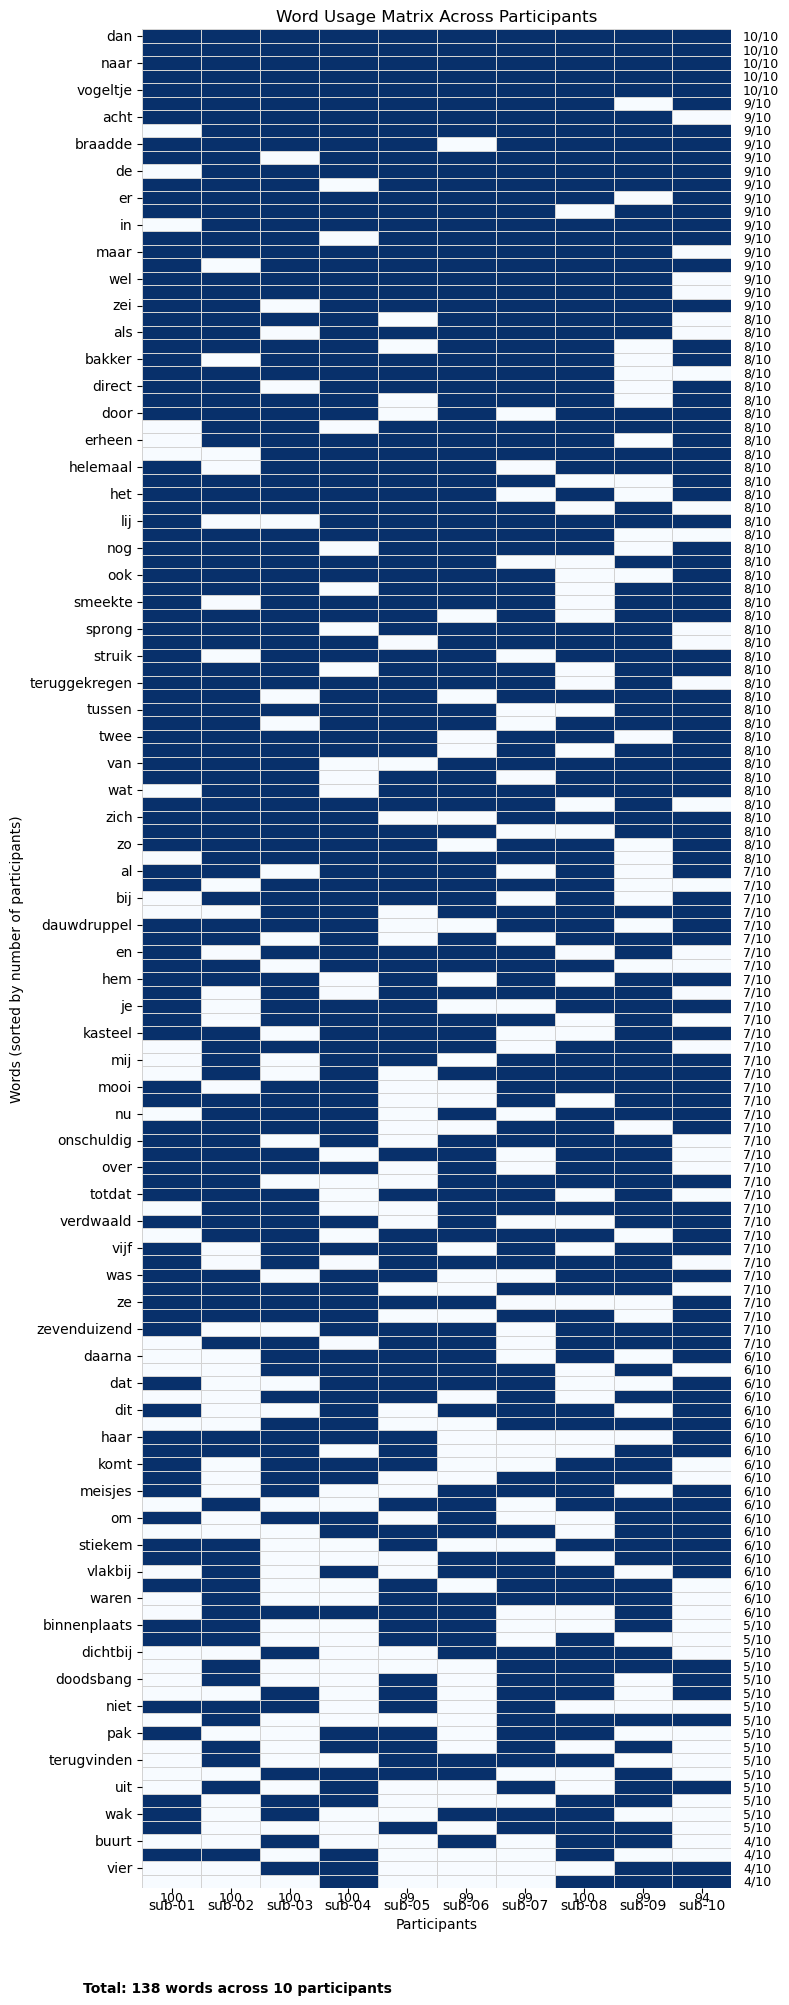

In [19]:
# Or use the interactive widget
word_matrix_widget = visualizer.interactive_word_matrix()
display(word_matrix_widget)